# 00 · Fashion Dataset Exploratory Data Analysis

## Purpose

This notebook is the single evidence base for every downstream modelling decision in
notebook `01`. It runs seven audits against the **raw, unmodified** files in `data/train/`
and reports what they show, including the parts that are inconvenient. It does **not**
clean the data, does **not** assign a train/validation/test split, and does **not** call
`train_test_split`. The only file this notebook writes is
`results/figures/dataset_overview.png` — a single report-candidate composite figure.

## The seven audits

1. **Schema audit** — physical CSV structure, phantom columns, blank/missing counts, the
   literal string `"NA"` versus true blanks in `usage`.
2. **Image integrity audit** — every training image's dimensions, colour mode, corruption
   status, and content hashes.
3. **ID reconciliation** — which CSV rows have no matching image file and vice versa.
4. **Exact-duplicate detection** — byte-identical and pixel-identical image groups.
5. **Near-duplicate candidate detection** — perceptual-hash (`dhash`) components that
   *may* represent visual duplicates, always treated as review candidates, never as
   confirmed duplicates.
6. **Target distribution, hierarchy, and association audit** — class balance for
   `articleType`, `season`, `gender`, `usage`; `articleType` → `masterCategory`/
   `subCategory` hierarchy conflicts; and the `gender`×`usage` association strength.
7. **Split-feasibility and open-decision audit** — which classes have enough support to
   appear in both a training and an evaluation partition, and which policy questions the
   evidence leaves unresolved for notebook `01` to decide.

The audits above are numbered independently of the section headings below. Audits 1–3 are
reported in Section 2, audit 4 in Section 3.1, audit 5 in Sections 3.2, 3.3 and 5.6,
audit 6 in Section 4, and audit 7 in Section 6. Section 5 is the stratified visual review
that supplies the human-judgement evidence for audits 5–7, and Section 7 holds the saved
composite figure and the decision ledger.

## Boundaries

- **No cleaning.** Corrupt images, blank labels, and phantom columns are counted and
  displayed, never dropped or imputed here.
- **No splitting.** No function in this notebook or in `fashion.eda` assigns a partition;
  `data/processed/splits.csv` does not exist yet and this notebook does not create it.
- **Fixed seed.** All sampling uses `RANDOM_SEED = 2753` from `fashion.config`, so every
  image grid below is reproducible.
- **Macro-F1 framing.** Because every target is class-imbalanced (see Section 5), the
  project reports macro-F1 as the primary classification metric in later notebooks;
  majority-class accuracy is calculated here only as a sanity floor, not as a target.
- **Candidates, not conclusions.** Perceptual near-duplicate groups are transitive
  connected components over a distance threshold — they are *review candidates*. Only a
  human visually confirming a group makes it an atomic duplicate group for splitting.

## 1. Environment

In [1]:
%matplotlib inline
from importlib.metadata import version

import matplotlib.pyplot as plt
import pandas as pd

from fashion.config import (
    FIGURE_DIR,
    RANDOM_SEED,
    TARGET_COLUMNS,
    TRAIN_CSV,
    TRAIN_IMAGE_DIR,
)
from fashion.eda import (
    audit_csv,
    audit_images,
    build_dataset_overview,
    cooccurrence_table,
    cramers_v,
    exact_duplicate_groups,
    hierarchy_conflicts,
    near_duplicate_groups,
    plot_image_grid,
    reconcile_ids,
    sample_ids,
    target_distribution,
    target_summary,
)

pd.set_option("display.max_rows", 130)
VERSIONS = {
    package: version(package)
    for package in ("pandas", "numpy", "matplotlib", "pillow", "jupyter")
}
VERSIONS

{'pandas': '3.0.5',
 'numpy': '2.5.2',
 'matplotlib': '3.11.1',
 'pillow': '12.3.0',
 'jupyter': '1.1.1'}

## 2. Schema and Image-Integrity Audit

We audit the raw CSV and the raw image directory independently, then reconcile their IDs.
`audit_csv` reads with `keep_default_na=False` so the literal string `"NA"` in `usage`
is never silently converted to a missing value. It also reconstructs `productDisplayName`
in memory from any comma-spilled phantom (`Unnamed:`) columns — the physical file is never
rewritten.

In [2]:
styles, schema_audit = audit_csv(TRAIN_CSV)
images = audit_images(TRAIN_IMAGE_DIR)
id_reconciliation = reconcile_ids(styles, images)

assert schema_audit.row_count == len(styles)
assert len(schema_audit.phantom_columns) == 2
assert schema_audit.blank_counts["usage"] != schema_audit.literal_na_usage_count
assert len(images) == images["id"].nunique()
assert id_reconciliation.matched_count + len(id_reconciliation.csv_only_ids) == styles["id"].nunique()
print("All Section 2 invariants hold.")

All Section 2 invariants hold.


### 2.1 Schema fields

In [3]:
schema_fields = pd.DataFrame(
    {
        "field": [
            "row_count",
            "physical_columns",
            "phantom_columns",
            "phantom_nonempty_counts",
            "duplicate_ids",
            "literal_na_usage_count",
        ],
        "value": [
            schema_audit.row_count,
            schema_audit.physical_columns,
            schema_audit.phantom_columns,
            schema_audit.phantom_nonempty_counts,
            schema_audit.duplicate_ids,
            schema_audit.literal_na_usage_count,
        ],
    }
)
with pd.option_context("display.max_colwidth", None):
    print(schema_fields.to_string(index=False))

                  field                                                                                                                                 value
              row_count                                                                                                                                 38617
       physical_columns (id, gender, masterCategory, subCategory, articleType, baseColour, season, year, usage, productDisplayName, Unnamed: 10, Unnamed: 11)
        phantom_columns                                                                                                            (Unnamed: 10, Unnamed: 11)
phantom_nonempty_counts                                                                                                 {'Unnamed: 10': 21, 'Unnamed: 11': 2}
          duplicate_ids                                                                                                                                    ()
 literal_na_usage_count                             

In [4]:
blank_counts = (
    pd.Series(schema_audit.blank_counts, name="blank_count")
    .rename_axis("column")
    .reset_index()
    .sort_values("blank_count", ascending=False, ignore_index=True)
)
blank_counts

,column,blank_count
0,season,20
1,usage,1
2,id,0
3,gender,0
4,masterCategory,0
5,subCategory,0
6,articleType,0
7,baseColour,0
8,year,0
9,productDisplayName,0


**Interpretation (feeds notebook `01`).** The CSV parses to the expected row count with
no duplicate `id` values, so row identity is trustworthy. Two phantom `Unnamed:` columns
exist in the physical header and some rows spill real text into them — `audit_csv` folds
that overflow back into `productDisplayName` in memory rather than discarding it, and the
non-empty counts above are the exact size of that overflow. `productDisplayName` is
free text and is **not** one of the four assignment targets, so this overflow does not
threaten label quality; it only means any later text-based work must use the
reconstructed column, not the raw physical one. Blank counts are target-specific: `season`
has 20 blank rows and `usage` has exactly one — quite different from the 71 rows holding
the literal string `"NA"` in `usage`, confirmed distinct by the assertion above.
Notebook `01` must not conflate "blank" with "the annotator's genuine NA label" when
deciding whether to drop or keep a row for a given target.

### 2.2 Image integrity and ID reconciliation

`audit_images` opens every file in `data/train/images_train/`, so the next cell reads all
training images once — expect this cell to take a few minutes.

In [5]:
corrupt_images = images.loc[images["error"].ne(""), ["id", "path", "error"]]
dimension_mode_counts = (
    images.groupby(["width", "height", "mode"], dropna=False)
    .size()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False, ignore_index=True)
)
print(f"Readable images: {images['error'].eq('').sum():,} / {len(images):,}")
corrupt_images

Readable images: 38,612 / 38,612


,id,path,error


In [6]:
dimension_mode_counts

,width,height,mode,count
0,60,80,RGB,38252
1,60,80,L,343
2,53,80,RGB,8
3,60,60,RGB,5
4,60,77,RGB,2
5,60,75,RGB,1
6,60,76,RGB,1


**Interpretation.** If `corrupt_images` is empty, every file in the training image
directory decoded successfully — a corruption-handling branch exists in `audit_images`
but this dataset does not exercise it, which notebook `01` should record rather than
assume for the held-out test images. The dimension/mode table shows how much the
supplied `60×80` claim actually holds: any row other than `(60, 80, RGB)` is a rewrite
target for the training pipeline's resize/format step, and any non-RGB mode row (e.g.
grayscale `L`) means the input pipeline must not assume three channels for every file.

In [7]:
unmatched_ids = pd.DataFrame(
    {
        "kind": ["csv_only (no image file)", "image_only (no CSV row)"],
        "count": [len(id_reconciliation.csv_only_ids), len(id_reconciliation.image_only_ids)],
        "ids": [id_reconciliation.csv_only_ids, id_reconciliation.image_only_ids],
    }
)
with pd.option_context("display.max_colwidth", None):
    print(unmatched_ids.to_string(index=False))

                    kind  count                                 ids
csv_only (no image file)      5 (12347, 39401, 39403, 39410, 39425)
 image_only (no CSV row)      0                                  ()


In [8]:
reconciliation_summary = pd.DataFrame(
    {
        "metric": [
            "csv rows (unique ids)",
            "image files",
            "matched ids",
            "csv-only ids",
            "image-only ids",
        ],
        "count": [
            styles["id"].nunique(),
            len(images),
            id_reconciliation.matched_count,
            len(id_reconciliation.csv_only_ids),
            len(id_reconciliation.image_only_ids),
        ],
    }
)
reconciliation_summary

,metric,count
0,csv rows (unique ids),38617
1,image files,38612
2,matched ids,38612
3,csv-only ids,5
4,image-only ids,0


**Interpretation (feeds notebook `01`).** The `ids` column above is the complete,
non-truncated tuple of every mismatched ID in each direction — not a sample — so notebook
`01` can exclude exactly these rows from any image-dependent computation without
re-deriving them. Any `csv_only` ID names a metadata row that **cannot** be used to train
or evaluate an image model, no matter how clean its labels are; those rows still count
for text-only summaries (e.g. label distribution) but must be excluded before an image
loader is built. `image_only` IDs, if any, are orphan files with no label and must never
enter training or evaluation.

## 3. Exact and Candidate Near-Duplicate Detection

Three hash families answer three different questions: `byte_sha256` catches literal file
copies, `pixel_sha256` catches re-encodings of the same decoded pixels, and `dhash` (a
64-bit perceptual hash) links images that merely *look* similar. Only the first two are
proof of duplication; the third is a **review candidate**, never an automatic verdict.

In [9]:
byte_duplicate_groups = exact_duplicate_groups(images, "byte_sha256")
pixel_duplicate_groups = exact_duplicate_groups(images, "pixel_sha256")
near_groups = near_duplicate_groups(images, max_distance=6)

duplicate_summary = pd.DataFrame(
    {
        "kind": ["byte-identical", "pixel-identical", "near-duplicate candidate"],
        "groups": [
            len(byte_duplicate_groups),
            len(pixel_duplicate_groups),
            len(near_groups),
        ],
        "images": [
            sum(map(len, byte_duplicate_groups)),
            sum(map(len, pixel_duplicate_groups)),
            sum(map(len, near_groups)),
        ],
    }
)
duplicate_summary

,kind,groups,images
0,byte-identical,636,1399
1,pixel-identical,636,1399
2,near-duplicate candidate,448,33131


### 3.1 Confirmed exact duplicates

In [10]:
byte_equals_pixel = byte_duplicate_groups == pixel_duplicate_groups
print(f"byte-identical groups == pixel-identical groups: {byte_equals_pixel}")

exact_groups_table = pd.DataFrame(
    {
        "group_index": range(len(pixel_duplicate_groups)),
        "size": [len(group) for group in pixel_duplicate_groups],
        "ids": pixel_duplicate_groups,
    }
)
# Printed in full: the brief requires every confirmed group's IDs, and the default
# display option would elide all but the first and last few rows.
with pd.option_context("display.max_rows", None, "display.max_colwidth", None):
    print(exact_groups_table.to_string(index=False))

byte-identical groups == pixel-identical groups: True
 group_index  size                          ids
           0     2               (10184, 10185)
           1     2               (10186, 10187)
           2     2               (10188, 10189)
           3     2               (10200, 10244)
           4     2               (10641, 10642)
           5     2               (10643, 10644)
           6     2               (10645, 10646)
           7     2               (10654, 10655)
           8     2               (10683, 10684)
           9     2               (11041, 11042)
          10     2               (11043, 11044)
          11     2               (11045, 11046)
          12     2               (11047, 11048)
          13     2               (11049, 11050)
          14     2               (11051, 11052)
          15     2               (11053, 11054)
          16     2               (11055, 11056)
          17     2               (11057, 11058)
          18     2               (

**Interpretation.** Every pixel-identical group is also byte-identical (or the two sets
differ, in which case some duplicates only match after re-encoding — check the boolean
above). Because these images are provably identical at the pixel or byte level, they are
**confirmed** duplicates, not candidates: notebook `01` must treat every group in
`exact_groups_table` as one atomic unit for split assignment, so no two members ever land
on opposite sides of a train/validation/held-out boundary.

### 3.2 Near-duplicate candidates — size distribution

A near-duplicate "group" here is a **connected component**: if A is close to B and B is
close to C, all three land in one group even if A and C are far apart (see the
`near_duplicate_groups` docstring). Before looking at individual images we first check
whether that transitive chaining has produced a distorted picture.

In [11]:
near_group_sizes = sorted(near_groups, key=len, reverse=True)
size_histogram = (
    pd.Series([len(group) for group in near_group_sizes], name="group_size")
    .value_counts()
    .rename_axis("group_size")
    .reset_index(name="num_groups")
    .sort_values("group_size", ignore_index=True)
)
size_histogram

,group_size,num_groups
0,2,308
1,3,71
2,4,28
3,5,9
4,6,12
5,7,5
6,8,3
7,9,2
8,10,2
9,14,2


In [12]:
giant_component = near_group_sizes[0]
giant_members = styles.set_index("id").reindex([i for i in giant_component if i in set(styles["id"])])
giant_span = pd.DataFrame(
    {
        "metric": ["component_size", "distinct_articleType", "distinct_masterCategory", "distinct_baseColour"],
        "value": [
            len(giant_component),
            giant_members["articleType"].nunique(),
            giant_members["masterCategory"].nunique(),
            giant_members["baseColour"].nunique(),
        ],
    }
)
giant_span

,metric,value
0,component_size,31568
1,distinct_articleType,115
2,distinct_masterCategory,6
3,distinct_baseColour,47


**Interpretation.** The size histogram is expected to show many small groups (pairs and
triples — the plausible genuine near-duplicates) and, separately, one dramatically larger
component. `giant_span` shows how many distinct `articleType`, `masterCategory`, and
`baseColour` values fall inside that single largest component. A component spanning most
of the label space is not evidence of 30,000+ real duplicate photos — at `60×80`
resolution, many product thumbnails share enough low-frequency structure (plain
background, centred garment) that `dhash` distance-6 chaining bridges unrelated products
through a long chain of weak links. We treat this giant component as a **known artifact
of the transitive-closure algorithm**, not as duplicate evidence, and do not attempt to
visually confirm it as a whole. The small groups are the credible near-duplicate
candidates; Section 3.3 lists all of them by ID and Section 5.6 samples them visually.

### 3.3 Complete candidate inventory (every reviewable component, by ID)

Section 5.6 can only *show* a bounded number of candidate images, so the complete
membership is recorded here instead: every candidate component small enough to be a
plausible product-photo set is listed in full, with its exact IDs, so a human reviewer can
adjudicate the whole queue without re-running the hash scan.

**Reviewability rule:** a component holding more than 1% of the readable images cannot
plausibly be one product photographed a handful of times, so it is separated out as a
chaining artifact rather than a review candidate. That rule is a size threshold, not a
verdict on any individual pair inside the artifact — none of those images is being called
a duplicate, and none is being called distinct either; they simply leave the review queue.

In [13]:
readable_image_count = int(images["error"].eq("").sum())
artifact_size_threshold = max(2, readable_image_count // 100)
reviewable_groups = tuple(
    group for group in near_groups if len(group) <= artifact_size_threshold
)
artifact_groups = tuple(
    group for group in near_groups if len(group) > artifact_size_threshold
)

candidate_inventory = pd.DataFrame(
    {
        "group_index": range(len(reviewable_groups)),
        "size": [len(group) for group in reviewable_groups],
        "ids": reviewable_groups,
    }
)
print(
    f"artifact size threshold (1% of {readable_image_count:,} readable images): "
    f"{artifact_size_threshold:,}"
)
print(
    f"reviewable candidate components: {len(reviewable_groups):,} "
    f"covering {sum(map(len, reviewable_groups)):,} images"
)
print(
    f"components excluded as chaining artifacts: {len(artifact_groups):,} "
    f"with sizes {[len(group) for group in artifact_groups]}"
)
# Printed one group per line rather than as a padded table: a single 189-member group
# would otherwise widen every one of the 447 rows to its length.
for index, group in enumerate(reviewable_groups):
    print(f"{index:>4}  size={len(group):>3}  {', '.join(group)}")

artifact size threshold (1% of 38,612 readable images): 386
reviewable candidate components: 447 covering 1,563 images
components excluded as chaining artifacts: 1 with sizes [31568]
   0  size=  3  10003, 10025, 10034
   1  size=  6  10056, 15461, 26324, 29043, 40110, 9770
   2  size=  2  10138, 19282
   3  size=  2  10197, 10254
   4  size=  2  10203, 10213
   5  size=  2  10231, 4600
   6  size=  2  10328, 16777
   7  size=  2  10331, 10334
   8  size=  2  10354, 47667
   9  size=  4  10374, 10411, 10514, 13961
  10  size=  2  10385, 18531
  11  size=  2  10400, 51540
  12  size=  3  10493, 4160, 9333
  13  size=  2  10606, 28429
  14  size=  2  10720, 28515
  15  size=  2  11002, 21707
  16  size=  3  11004, 11005, 11486
  17  size=  2  11006, 31834
  18  size=  3  11027, 2920, 2921
  19  size=  2  11133, 11138
  20  size=  2  11180, 11193
  21  size=  3  11307, 14321, 14392
  22  size=  2  11309, 13627
  23  size=  5  11487, 2580, 2590, 30076, 51832
  24  size=  2  11690, 11695
  

**Decision boundary.** Only a group a human has *looked at and accepted* becomes an
atomic duplicate group for splitting, exactly like the confirmed exact-duplicate groups
above. An unconfirmed near-duplicate candidate — including every component listed in
Section 3.3 and every member of the giant component — must not be merged into another
image's split assignment.

## 4. Target Distributions, Hierarchy Conflicts, and Label Association

This section characterises the four assignment targets — `articleType`, `season`,
`gender`, `usage` — on their own terms: how skewed each is, whether `articleType` maps
cleanly onto the coarser `masterCategory`/`subCategory` hierarchy, and how strongly
`gender` and `usage` co-vary.

In [14]:
target_summaries = target_summary(styles, TARGET_COLUMNS)
target_summaries

,target,rows,classes_including_blank,blank_count,majority_label,majority_count,majority_accuracy,minority_count,imbalance_ratio
0,articleType,38617,125,0,Tshirts,6781,0.175596,1,6781.000000
1,season,38617,5,20,Summer,19137,0.495559,1567,12.212508
2,gender,38617,5,0,Men,20918,0.541679,645,32.431008
3,usage,38617,10,1,Casual,29641,0.767564,1,29641.000000


**Interpretation.** `majority_accuracy` is the accuracy of always predicting the single
most common non-blank label — a sanity floor, not a target. `imbalance_ratio` compares
that majority label's count to the rarest non-blank label's count; a large ratio means a
model minimising plain accuracy can ignore the tail entirely, which is exactly why this
project reports macro-F1 (which weights every class equally) rather than accuracy as the
primary metric.

### 4.1 Full distributions (every class, not just the largest)

In [15]:
article_type_distribution = target_distribution(styles, "articleType")
article_type_distribution

,label,count,share,rank
0,Tshirts,6781,0.175596,1
1,Shirts,3089,0.079991,2
2,Casual Shoes,2683,0.069477,3
3,Watches,2252,0.058316,4
4,Sports Shoes,1991,0.051558,5
5,Tops,1614,0.041795,6
6,Kurtas,1556,0.040293,7
7,Handbags,1439,0.037263,8
8,Heels,1048,0.027138,9
9,Sunglasses,1047,0.027112,10


In [16]:
def support_bucket(count: int) -> str:
    if count == 1:
        return "1"
    if count == 2:
        return "2"
    if count <= 4:
        return "3-4"
    if count <= 9:
        return "5-9"
    if count <= 19:
        return "10-19"
    return "20+"


bucket_order = ["1", "2", "3-4", "5-9", "10-19", "20+"]
article_type_buckets = (
    article_type_distribution.assign(support_bucket=article_type_distribution["count"].map(support_bucket))
    .groupby("support_bucket")
    .agg(num_classes=("label", "size"), total_rows=("count", "sum"))
    .reindex(bucket_order)
    .fillna(0)
    .astype({"num_classes": int, "total_rows": int})
)
article_type_buckets

,num_classes,total_rows
support_bucket,,
1,7,7
2,8,16
3-4,7,24
5-9,11,75
10-19,16,217
20+,76,38278


In [17]:
season_distribution = target_distribution(styles, "season")
season_distribution

,label,count,share,rank
0,Summer,19137,0.495559,1
1,Fall,10512,0.272212,2
2,Winter,7381,0.191133,3
3,Spring,1567,0.040578,4
4,<BLANK>,20,0.000518,5


In [18]:
gender_distribution = target_distribution(styles, "gender")
gender_distribution

,label,count,share,rank
0,Men,20918,0.541679,1
1,Women,14160,0.366678,2
2,Unisex,2080,0.053862,3
3,Boys,814,0.021079,4
4,Girls,645,0.016702,5


In [19]:
usage_distribution = target_distribution(styles, "usage")
usage_distribution

,label,count,share,rank
0,Casual,29641,0.767564,1
1,Sports,3940,0.102028,2
2,Ethnic,2570,0.066551,3
3,Formal,2300,0.059559,4
4,NA,71,0.001839,5
5,Smart Casual,55,0.001424,6
6,Travel,25,0.000647,7
7,Party,13,0.000337,8
8,<BLANK>,1,0.000026,9
9,Home,1,0.000026,10


**Interpretation.** `articleType` spans a long tail: the support-bucket table shows how
many classes fall into each feasibility band, from singleton classes with exactly one
example up to classes with dozens or thousands. `season` and `usage` each carry a small
blank/`<BLANK>` count that is distinct from any real label and from the literal `"NA"`
string in `usage`. `gender` has no blanks but is still imbalanced across its five labels.
None of these distributions are edited here — notebook `01` decides what, if anything, to
do about the tail.

### 4.2 `articleType` → hierarchy conflicts

In [20]:
hierarchy_issues = hierarchy_conflicts(styles)
hierarchy_issues

,articleType,master_categories,subcategories,rows,master_category_count,subcategory_count
0,Backpacks,"(Accessories, Free Items)","(Bags, Free Gifts)",710,2,2
1,Belts,"(Accessories, Apparel)","(Belts, Topwear)",795,2,2
2,Clutches,"(Accessories, Free Items)","(Bags, Free Gifts)",223,2,2
3,Dresses,"(Apparel,)","(Dress, Topwear)",345,1,2
4,Flip Flops,"(Footwear,)","(Flip Flops, Sandal)",863,1,2
5,Handbags,"(Accessories, Free Items)","(Bags, Free Gifts)",1439,2,2
6,Kajal and Eyeliner,"(Personal Care,)","(Eyes, Makeup)",13,1,2
7,Laptop Bag,"(Accessories, Free Items)","(Bags, Free Gifts)",79,2,2
8,Messenger Bag,"(Accessories,)","(Accessories, Bags)",43,1,2
9,Perfume and Body Mist,"(Accessories, Personal Care)","(Fragrance, Perfumes)",557,2,2


**Interpretation.** Every row above is an `articleType` value that maps to more than one
`masterCategory` and/or `subCategory` across the dataset — a labelling inconsistency in
the *hierarchy*, not in `articleType` itself. Some of these are structurally intentional
(e.g. an accessory that is also sold as a free promotional item), while others look like
plain annotation drift (the same garment type filed under two unrelated master
categories). Section 5.3 visually samples a subset of these labels so the two explanations
can be told apart. This table is the complete list of conflicting labels; notebook `01`
must decide per-label whether to trust `articleType` or fold it into a cleaned hierarchy,
but that decision is out of scope here.

### 4.3 `gender` × `usage` co-occurrence and association

In [21]:
gender_usage = cooccurrence_table(styles, "gender", "usage")
gender_usage

usage,<BLANK>,Casual,Ethnic,Formal,Home,NA,Party,Smart Casual,Sports,Travel
gender,,,,,,,,,,
Boys,0,783,10,0,0,0,0,0,21,0
Girls,0,635,8,0,0,0,0,0,2,0
Men,1,15691,90,2193,0,22,0,44,2876,1
Unisex,0,1758,0,1,1,18,0,0,282,20
Women,0,10774,2462,106,0,31,13,11,759,4


In [22]:
gender_usage_v = cramers_v(styles["gender"], styles["usage"])
print(f"Cramer's V (gender, usage) = {gender_usage_v:.4f}")

Cramer's V (gender, usage) = 0.2071


**Interpretation.** Cramér's V is bounded in `[0, 1]`; the co-occurrence table shows
*where* the association above comes from (e.g. certain usage categories concentrating in
one gender). Whatever value this measures, **label association is not evidence that a
shared model improves generalization** — it only justifies running a controlled,
independent-heads-versus-multitask comparison in the modelling notebooks and reporting
which one actually generalises better. The EDA stops at "these labels co-vary"; it does
not conclude "therefore share a model."

## 5. Stratified Visual Review

Every grid below states its sampling rule and seed before the code that builds it, uses
`RANDOM_SEED = 2753` for every stochastic choice, and is followed by a figure that is
closed immediately after display (`plt.close(figure)`) so repeated grids do not retain
open figure buffers.

### 5.1 The five most common `articleType` labels

**Rule:** the 5 labels with the highest `articleType` counts (from `article_type_distribution`
above), 4 images sampled per label via `sample_ids(..., seed=RANDOM_SEED)`.

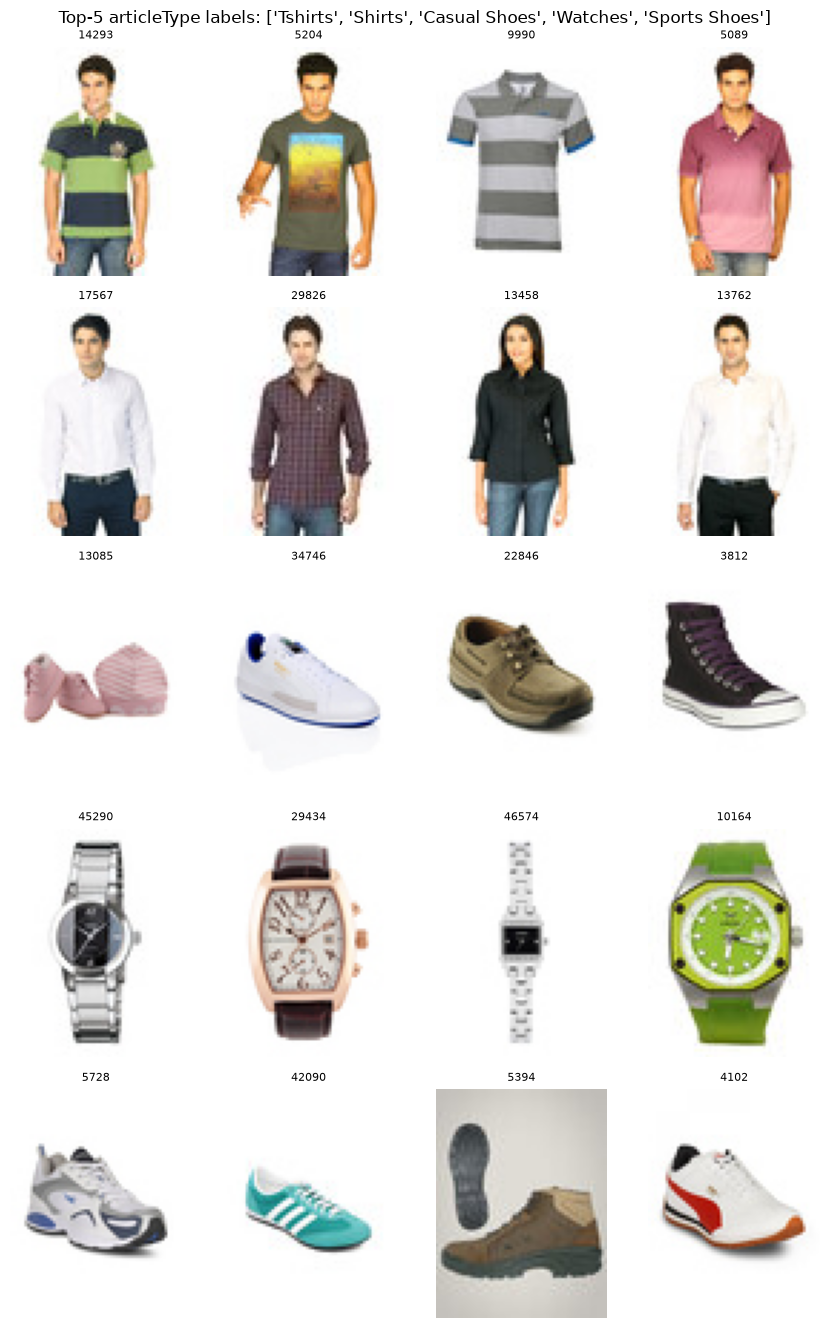

In [23]:
top5_labels = article_type_distribution.head(5)["label"].tolist()
top5_ids = sample_ids(styles, "articleType", top5_labels, per_label=4, seed=RANDOM_SEED)
top5_figure = plot_image_grid(top5_ids, TRAIN_IMAGE_DIR, f"Top-5 articleType labels: {top5_labels}", columns=4)
plt.show()
plt.close(top5_figure)

**Interpretation.** These are the classes a majority-baseline or an under-trained model
will default to; visually confirming they are coherent (same garment, consistent framing)
rules out "the majority class is itself a mislabeled grab-bag" as an explanation for a
model leaning on it.

### 5.2 Every singleton and doubleton `articleType`

**Rule:** every `articleType` label with count ≤ 2 (from `article_type_distribution`),
up to 2 images per label, sampled via `sample_ids(..., seed=RANDOM_SEED)`. This covers all
such labels in one grid because there are few enough to stay readable.

15 articleType labels have count <= 2: ['Baby Dolls', 'Concealer', 'Key chain', 'Lehenga Choli', 'Rain Jacket', 'Rain Trousers', 'Robe', 'Shapewear', 'Body Wash and Scrub', 'Cushion Covers', 'Ipad', 'Lounge Tshirts', 'Shoe Laces', 'Suits', 'Ties and Cufflinks']


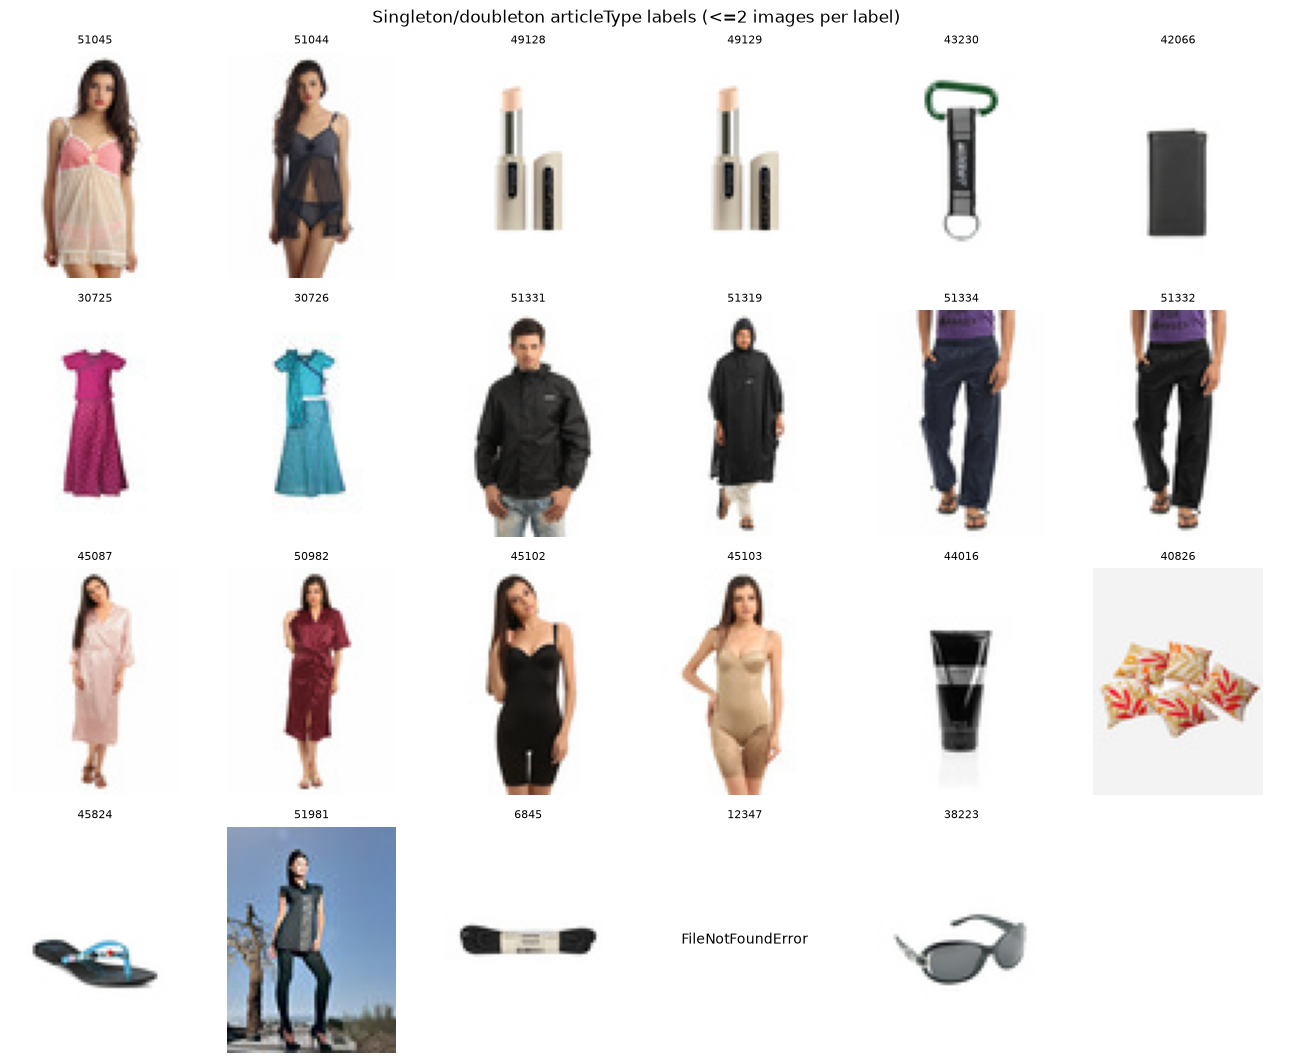

In [24]:
rare_labels = article_type_distribution.loc[article_type_distribution["count"].le(2), "label"].tolist()
print(f"{len(rare_labels)} articleType labels have count <= 2: {rare_labels}")
rare_ids = sample_ids(styles, "articleType", rare_labels, per_label=2, seed=RANDOM_SEED)
rare_figure = plot_image_grid(rare_ids, TRAIN_IMAGE_DIR, "Singleton/doubleton articleType labels (<=2 images per label)", columns=6)
plt.show()
plt.close(rare_figure)

**Interpretation.** A singleton class cannot appear in both a training split and an
evaluation split at once, so it can never be *fairly* evaluated no matter how it is
trained; a doubleton can support at most one training example and one evaluation example,
with zero margin for a validation slice. Whether these images look like genuine rare
products or like annotation noise (e.g. a one-off mislabel of a common garment) is a
judgment call notebook `01` must make per label — this grid is the evidence for that call,
not the call itself.

### 5.3 Hierarchy-conflict label samples

**Rule:** the 8 highest-support labels from `hierarchy_issues` (of 20 total, all listed in
Section 4.2), 2 images per label via `sample_ids(..., seed=RANDOM_SEED)` — capped to 8
labels so the grid stays readable; the full conflict list remains in the table above.

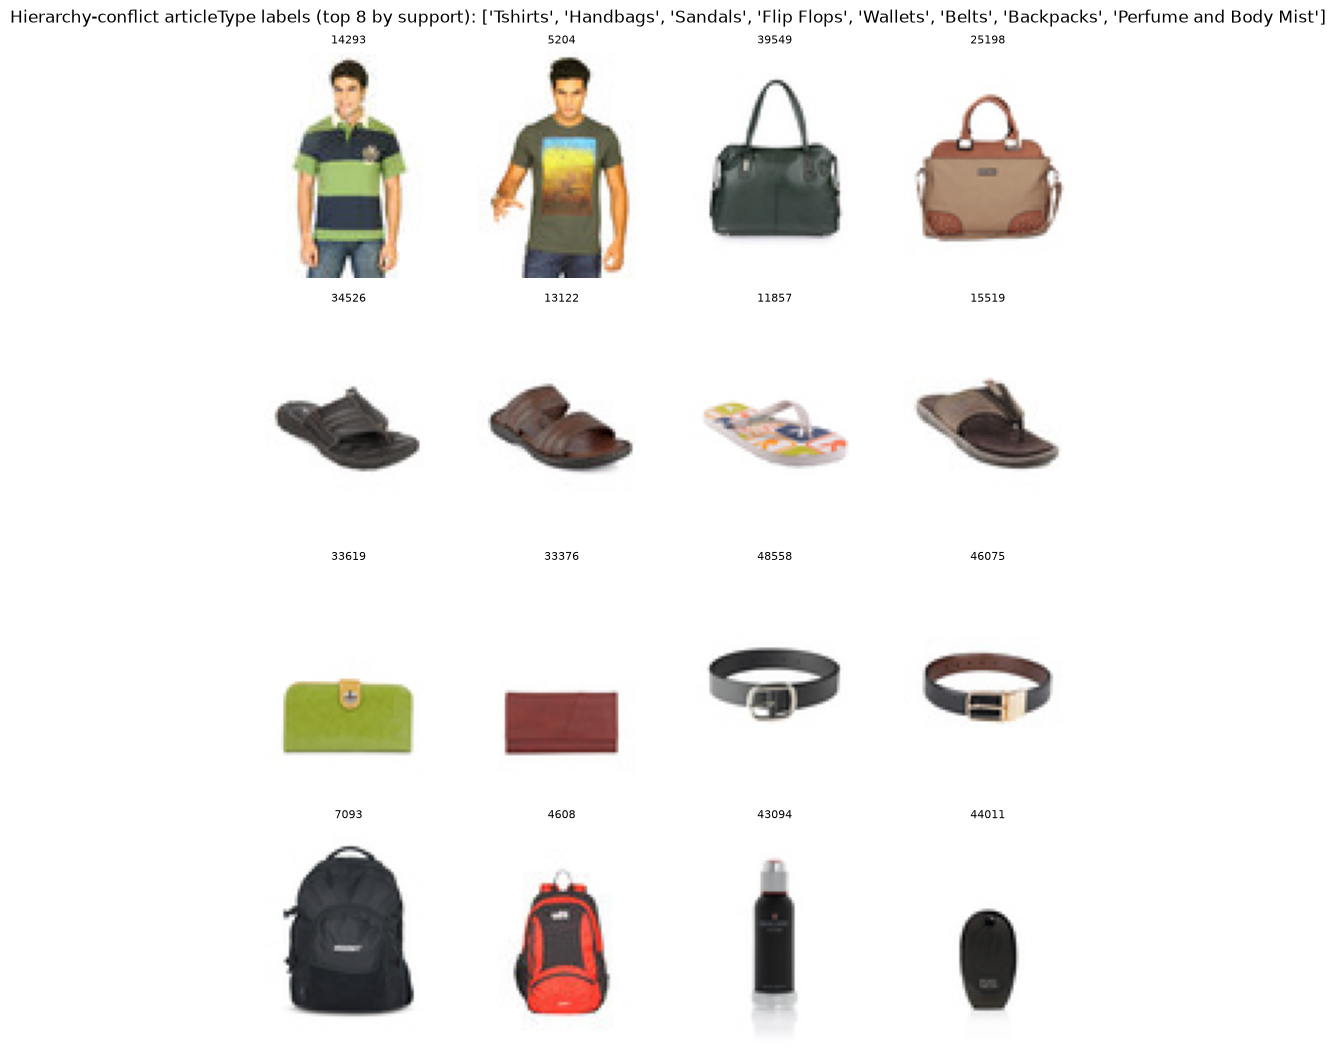

In [25]:
conflict_labels = hierarchy_issues.sort_values("rows", ascending=False).head(8)["articleType"].tolist()
conflict_ids = sample_ids(styles, "articleType", conflict_labels, per_label=2, seed=RANDOM_SEED)
conflict_figure = plot_image_grid(conflict_ids, TRAIN_IMAGE_DIR, f"Hierarchy-conflict articleType labels (top 8 by support): {conflict_labels}", columns=4)
plt.show()
plt.close(conflict_figure)

**Interpretation.** For each label above, compare what the image actually shows against
the multiple `masterCategory`/`subCategory` values recorded for that `articleType` in
Section 4.2. Where the image plausibly fits either category (e.g. a belt-like accessory
also filed as topwear trim) the conflict looks like a genuine dual-use product; where the
image obviously belongs to one category and the other assignment looks like a fat-finger
label, it is annotation noise. This grid cannot resolve every label — it demonstrates the
*kind* of evidence needed before notebook `01` picks a hierarchy-repair policy.

### 5.4 Blank targets and literal `usage == "NA"`

**Rule:** all rows with blank `season`, the single blank `usage` row, and up to 10 rows
with literal `usage == "NA"`, sampled via `sample_ids(..., seed=RANDOM_SEED)`.

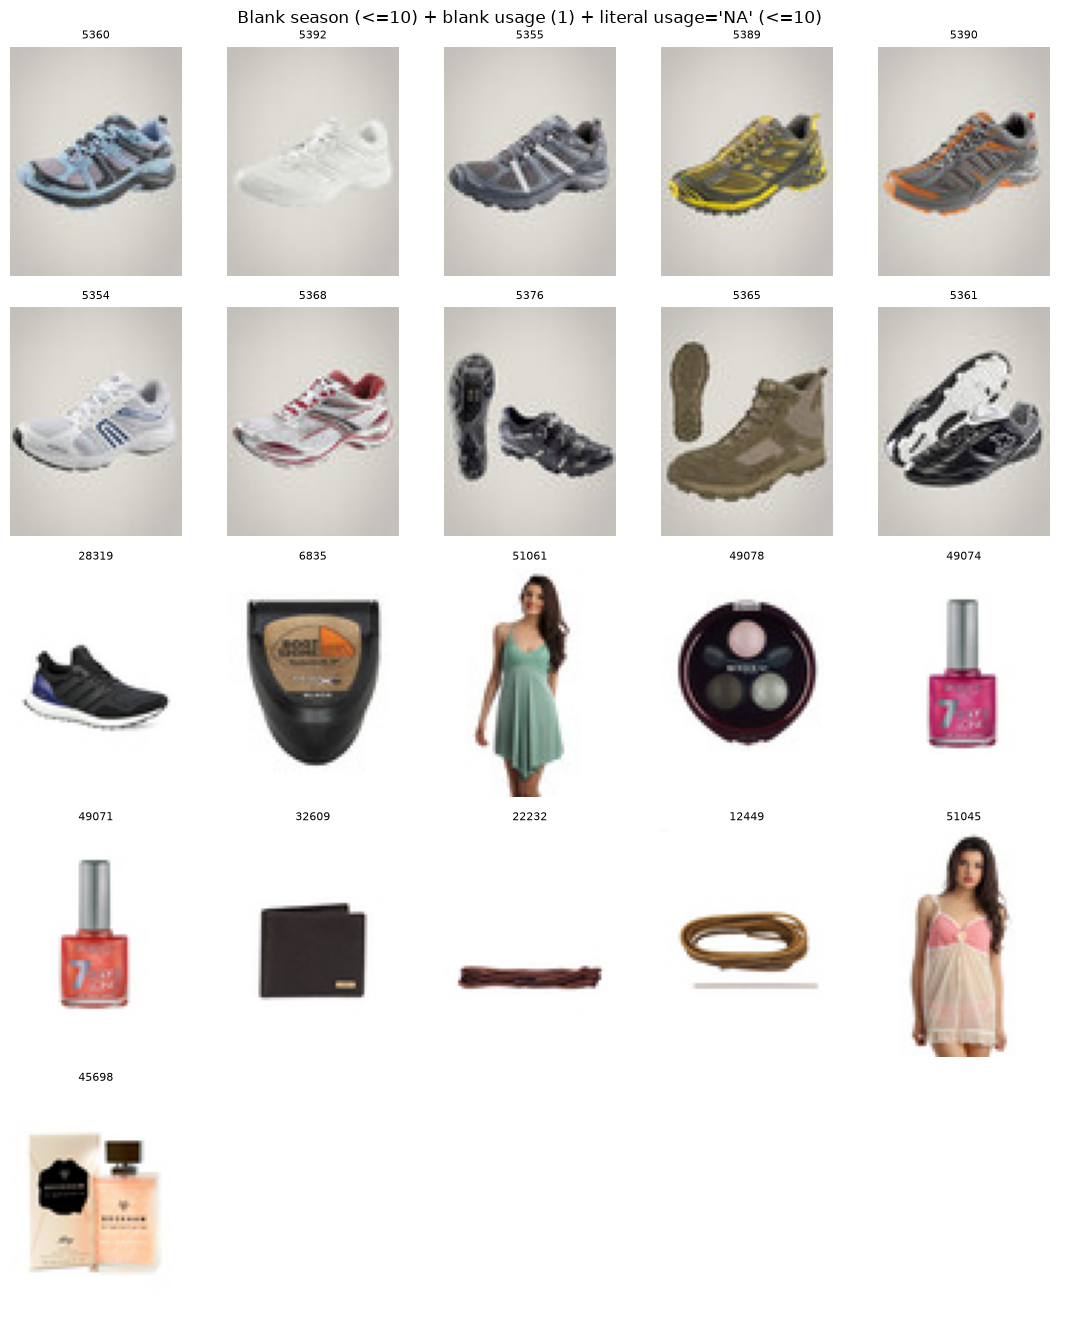

In [26]:
blank_season_ids = sample_ids(styles, "season", ["<BLANK>"], per_label=10, seed=RANDOM_SEED)
blank_usage_ids = sample_ids(styles, "usage", ["<BLANK>"], per_label=1, seed=RANDOM_SEED)
na_usage_ids = sample_ids(styles, "usage", ["NA"], per_label=10, seed=RANDOM_SEED)
missing_label_ids = blank_season_ids + blank_usage_ids + na_usage_ids
missing_figure = plot_image_grid(
    missing_label_ids,
    TRAIN_IMAGE_DIR,
    "Blank season (<=10) + blank usage (1) + literal usage='NA' (<=10)",
    columns=5,
)
plt.show()
plt.close(missing_figure)

**Interpretation.** Blank `season` and blank `usage` are missing annotations — the
product is simply unrated for that target. Literal `usage == "NA"` is different: an
annotator explicitly recorded "not applicable" rather than leaving the field empty, which
Section 4.1's distribution already counts separately from blanks. Because missingness is
target-specific, a row with a blank `season` can still carry a perfectly usable `gender`
or `articleType` label — notebook `01` must not drop these rows from every task just
because one target is unrated.

### 5.5 Pixel-exact duplicate groups

**Rule:** the first 3 of the confirmed pixel-identical groups (deterministic order from
`exact_duplicate_groups`, no randomness needed since the grouping itself is fully
deterministic), every member shown.

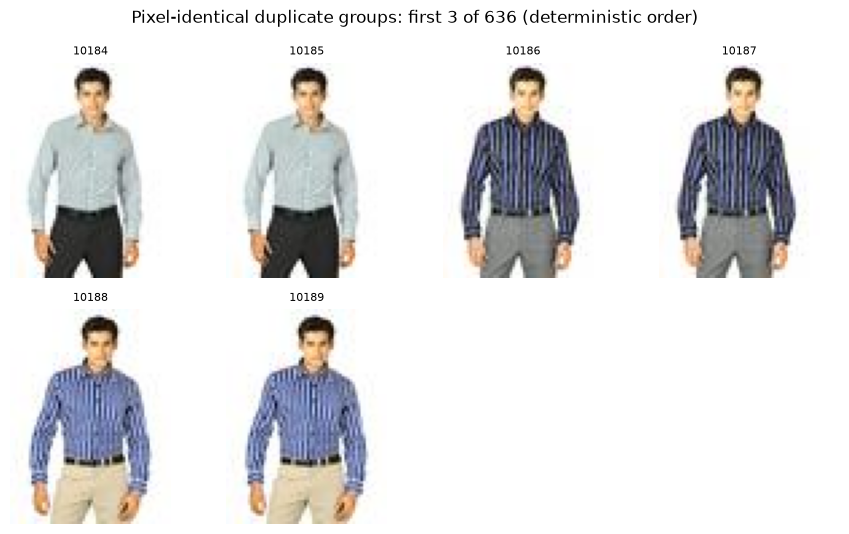

In [27]:
sampled_exact_groups = pixel_duplicate_groups[:3]
exact_sample_ids = [image_id for group in sampled_exact_groups for image_id in group]
exact_figure = plot_image_grid(
    exact_sample_ids,
    TRAIN_IMAGE_DIR,
    f"Pixel-identical duplicate groups: first 3 of {len(pixel_duplicate_groups)} (deterministic order)",
    columns=4,
)
plt.show()
plt.close(exact_figure)

**Interpretation.** These groups are confirmed, not candidates — the pixel hash proves
byte-for-byte identical decoded content. Visual review here is a plausibility check on
the hashing pipeline, not a confirmation step; every group in `exact_groups_table` (all
636, not only these 3) must be treated as atomic for splitting regardless of what the
sample looks like.

### 5.6 Near-duplicate candidate groups

**Rule (typical case):** a seeded random sample of 3 pair-sized (`size == 2`) candidate
groups — the modal group size — using `random.Random(RANDOM_SEED)`, every member shown.

**Rule (large candidates):** the two largest *reviewable* components under Section 3.3's
1%-of-corpus rule, deterministic order, first 6 members of each (sorted IDs).

**Rule (giant component):** the first 12 (sorted) IDs from the single oversized component
separated out in Sections 3.2–3.3, to demonstrate visually why it is treated as a chaining
artifact rather than a duplicate cluster.

These caps bound how many images are rendered, not how much evidence exists: Section 3.3
already records every reviewable component's complete membership by ID.

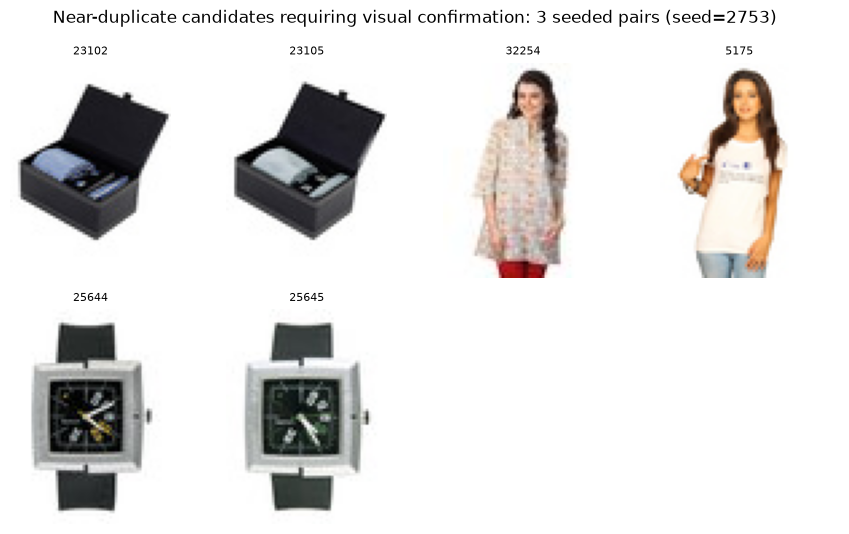

In [28]:
import random

pair_groups = [group for group in near_groups if len(group) == 2]
seeded_pairs = random.Random(RANDOM_SEED).sample(pair_groups, k=min(3, len(pair_groups)))
pair_sample_ids = [image_id for group in seeded_pairs for image_id in group]
pair_figure = plot_image_grid(
    pair_sample_ids,
    TRAIN_IMAGE_DIR,
    f"Near-duplicate candidates requiring visual confirmation: 3 seeded pairs (seed={RANDOM_SEED})",
    columns=4,
)
plt.show()
plt.close(pair_figure)

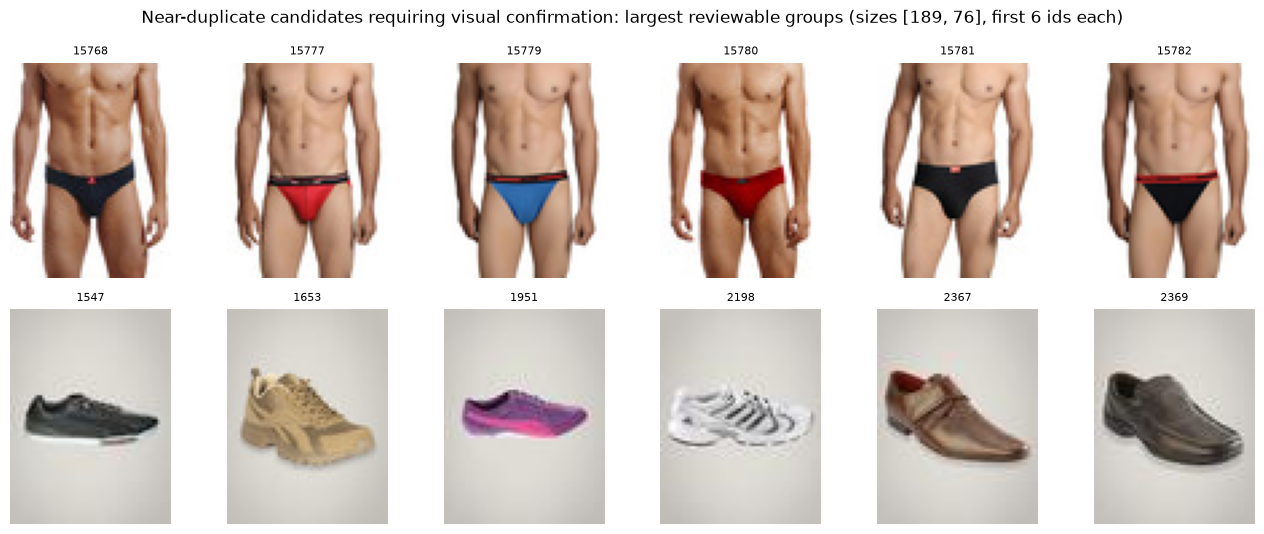

In [29]:
large_candidate_groups = sorted(reviewable_groups, key=len, reverse=True)[:2]
large_sample_ids = [image_id for group in large_candidate_groups for image_id in sorted(group)[:6]]
large_figure = plot_image_grid(
    large_sample_ids,
    TRAIN_IMAGE_DIR,
    f"Near-duplicate candidates requiring visual confirmation: largest reviewable groups (sizes {[len(g) for g in large_candidate_groups]}, first 6 ids each)",
    columns=6,
)
plt.show()
plt.close(large_figure)

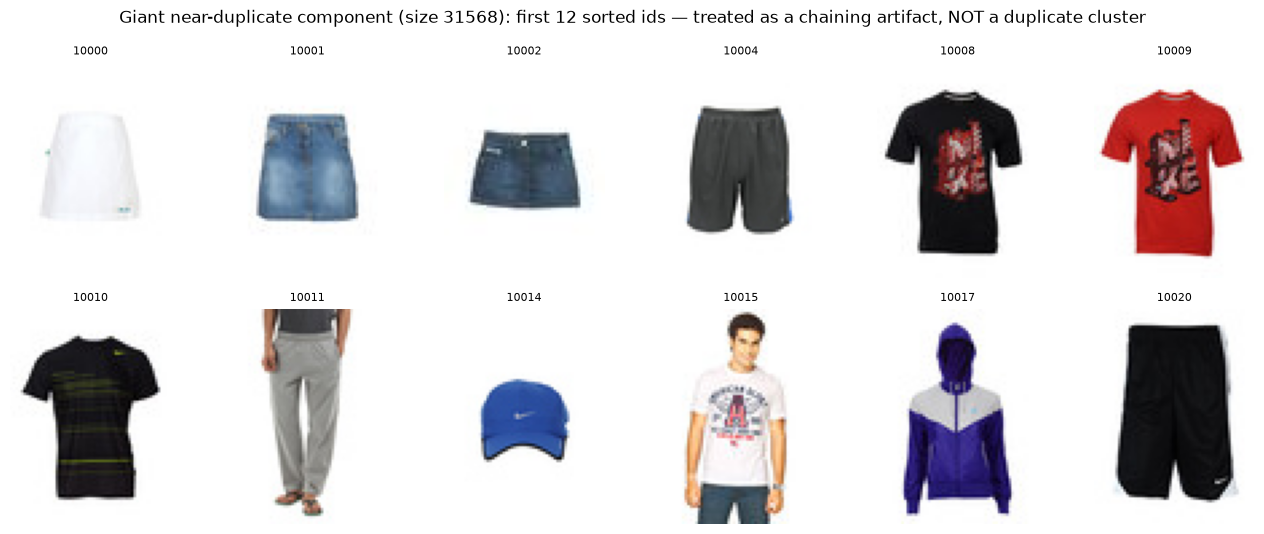

In [30]:
giant_sample_ids = sorted(giant_component)[:12]
giant_figure = plot_image_grid(
    giant_sample_ids,
    TRAIN_IMAGE_DIR,
    f"Giant near-duplicate component (size {len(giant_component)}): first 12 sorted ids — treated as a chaining artifact, NOT a duplicate cluster",
    columns=6,
)
plt.show()
plt.close(giant_figure)

**Interpretation.** The three seeded pairs above are a real, honest mix, which is exactly
why this notebook refuses to auto-accept them. The first pair (two accessory gift-set
boxes) and the third pair (two Fastrack watches) are colourway variants of one product
shot in an identical studio setup — plausible near-duplicates a human should examine and
probably promote to confirmed status, since they would leak almost all of their visual
content across a split boundary. The second pair is different in kind: a printed kurti and
a plain white t-shirt, two unrelated garments that share only a full-length female model
on a white background. That pair is a `dhash` collision, not a duplicate — at 60×80 the
hash encodes the pose and background far more strongly than the garment. One grid with a
two-thirds hit rate is already enough to falsify "every near-duplicate candidate is a real
duplicate" — exactly the failure mode Section 3.2 predicted for a purely transitive,
threshold-based grouping.

The two large reviewable components fail in a third, more interesting way. The larger one
is a *photographic template* cluster: every member is a different Facit briefs product
shot on the same male torso in the same crop, so the images are near-identical everywhere
except the garment itself. The second is a mixed footwear cluster — Puma, Reebok, Adidas
and Red Tape shoes spanning `Casual Shoes`, `Sports Shoes` and `Formal Shoes` — linked
only by a single shoe silhouette on a grey background. Neither is a set of duplicate
photographs, yet the first is a genuine leakage risk worth a human ruling and the second
is not, which is precisely the distinction a threshold cannot make on its own. The giant
component makes the point at full scale: its first twelve members are skirts, shorts,
t-shirts, track pants, a cap and a jacket, with no shared product identity whatsoever.

**No group on this page is auto-accepted.** Only a human explicitly marking a specific
group as confirmed (recorded outside this notebook) may turn it into an atomic split unit;
everything here remains a "requires visual confirmation" candidate, and the false
positives above are the concrete reason why.

## 6. Split-Feasibility and Open-Decision Evidence

Before any split exists, we can already say which labels *could* support one. The table
below classifies every label of every target by how many rows carry it.

In [31]:
def evaluation_status(count: int) -> str:
    if count == 1:
        return "cannot appear in both training and evaluation"
    if count == 2:
        return "cannot support train/validation/held-out coverage"
    if count <= 4:
        return "coverage possible but metric unstable"
    return "eligible for coverage checks"


feasibility_rows = []
for target in TARGET_COLUMNS:
    distribution = target_distribution(styles, target)
    for _, row in distribution.iterrows():
        feasibility_rows.append(
            {
                "target": target,
                "label": row["label"],
                "count": int(row["count"]),
                "evaluation_status": evaluation_status(int(row["count"])),
            }
        )
support_feasibility = pd.DataFrame(feasibility_rows)
print(support_feasibility.to_string(index=False))

     target                 label  count                                 evaluation_status
articleType               Tshirts   6781                      eligible for coverage checks
articleType                Shirts   3089                      eligible for coverage checks
articleType          Casual Shoes   2683                      eligible for coverage checks
articleType               Watches   2252                      eligible for coverage checks
articleType          Sports Shoes   1991                      eligible for coverage checks
articleType                  Tops   1614                      eligible for coverage checks
articleType                Kurtas   1556                      eligible for coverage checks
articleType              Handbags   1439                      eligible for coverage checks
articleType                 Heels   1048                      eligible for coverage checks
articleType            Sunglasses   1047                      eligible for coverage checks

In [32]:
support_feasibility["evaluation_status"].value_counts()

evaluation_status
eligible for coverage checks                         121
cannot appear in both training and evaluation          9
cannot support train/validation/held-out coverage      8
coverage possible but metric unstable                  7
Name: count, dtype: int64

**Evidence-bound conclusions for notebook `01`:**

- CSV rows without readable images (Section 2.2's `csv_only` set) cannot be used by image
  models, regardless of how good their labels are.
- Phantom columns (Section 2.1) carry no model information; they only recorded raw-CSV
  overflow that `audit_csv` already folded back into `productDisplayName`.
- Missingness is target-specific (Section 4.1/5.4): notebook `01` must not discard a row
  for every task just because one target's label is blank.
- Confirmed duplicate groups (Section 3.1) must remain atomic — never split across
  training and evaluation.
- The rare-`articleType` policy (Section 5.2, and the `"1"`/`"2"` rows above) remains
  **unresolved**: notebook `01` must explicitly state whether task-level exclusion of
  singleton/doubleton classes, or merging them into a coarser hierarchy level, preserves
  the assignment's actual target most honestly — this notebook only supplies the evidence,
  not the ruling.
- Shared `gender`/`usage` learning (Section 4.3) remains a **controlled experiment**, not
  an EDA conclusion — the association measured here justifies running the comparison, not
  skipping it.
- Visual-search relevance (Task 4 of the assignment) has no human relevance labels, so any
  Top-K evaluation must compare **at least** exact `articleType` match, shared
  `subCategory` match, and one documented hierarchical rule as competing relevance
  definitions, and report all three rather than picking one silently.

## 7. Dataset Overview Figure and Decision Ledger

The only figure this notebook saves to disk: a four-panel composite summarising the
`articleType` long tail and the `season`/`gender`/`usage` distributions, annotated with
per-bar counts and a headline summary of readable images and unmatched IDs.

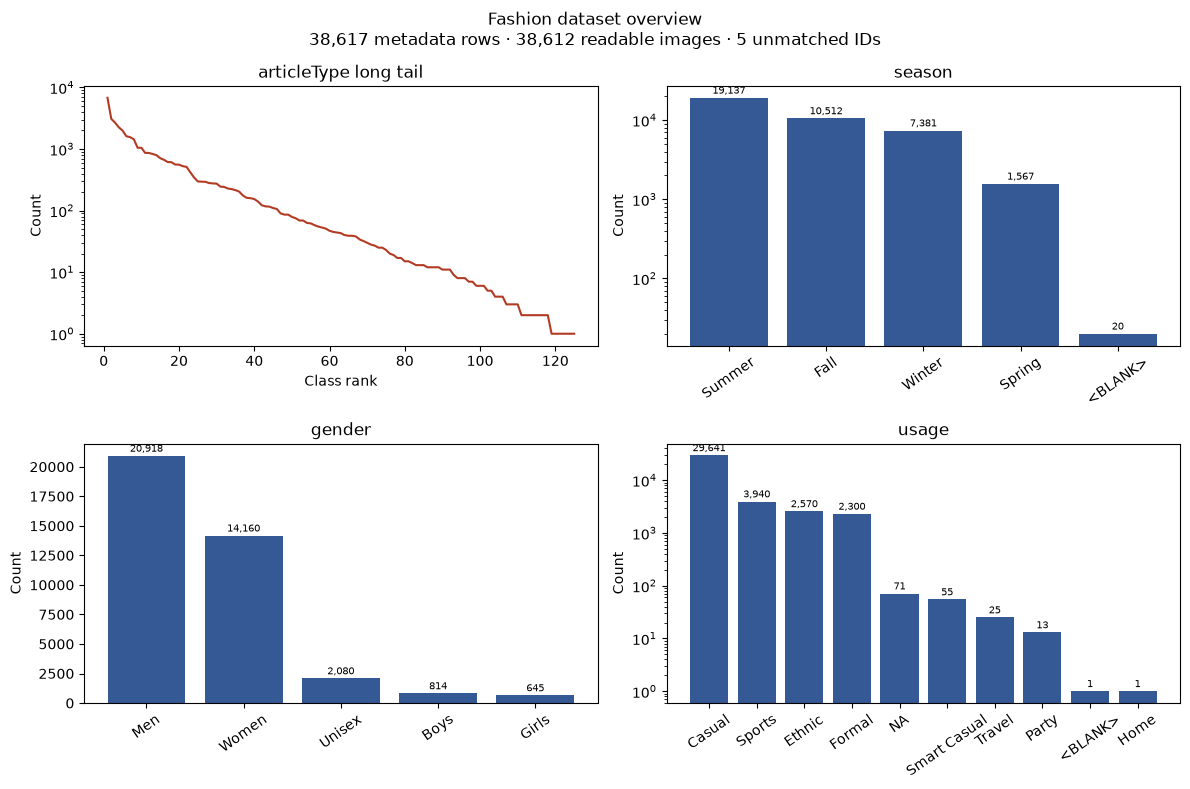

Saved /Users/lintran/Documents/Coding/MLA2/results/figures/dataset_overview.png (177,656 bytes)


In [33]:
overview_path = FIGURE_DIR / "dataset_overview.png"
overview_figure = build_dataset_overview(styles, images, overview_path)
plt.show()
plt.close(overview_figure)
assert overview_path.is_file()
print(f"Saved {overview_path} ({overview_path.stat().st_size:,} bytes)")

### Decision ledger

| Decision | Evidence | Status | Downstream rule | Follow-up |
|---|---|---|---|---|
| CSV parsing must preserve literal `"NA"` | Section 2.1 schema fields; `literal_na_usage_count` ≠ `blank_counts["usage"]` | Resolved | Always read `styles_train.csv`/`styles_prediction.csv` with `keep_default_na=False` | None |
| Phantom `Unnamed:` columns hold real overflow text | Section 2.1 `phantom_nonempty_counts` | Resolved | Reconstruct `productDisplayName` from phantom columns in memory; never treat phantom columns as model features | None |
| Unmatched CSV/image IDs must be excluded from image pipelines | Section 2.2 `unmatched_ids`, `reconciliation_summary` | Resolved | Any image-model dataloader filters to `id_reconciliation.matched_count` rows only | Confirm the held-out test set (`data/test/`) has the same or a different mismatch profile before reusing this logic there |
| Image corruption handling | Section 2.2 `corrupt_images` | Resolved for this dataset (no corrupt files found) | Loader must still catch `OSError`/`UnidentifiedImageError` defensively | Re-check when the test image set is audited |
| Dimensions/modes are not uniformly `60×80` RGB | Section 2.2 `dimension_mode_counts` | Resolved (documented, not fixed here) | Preprocessing must resize/convert to a single canonical shape and mode before batching | None |
| Confirmed exact duplicate groups | Section 3.1 `exact_groups_table` | Resolved | Every group is one atomic unit for split assignment | None |
| Near-duplicate candidates, including one oversized chained component | Section 3.2 size distribution, Section 3.3 complete inventory, Section 5.6 sampled grids | Unresolved by design | No candidate is auto-accepted; only human-confirmed groups become atomic | A human reviewer must adjudicate the full candidate inventory listed in Section 3.3 before notebook `01` builds the split |
| Missing labels are target-specific | Section 4.1, Section 5.4 | Resolved | Do not drop a row for every task because one target is blank | None |
| Rare `articleType` classes (singleton/doubleton/long tail) | Section 4.1 support buckets, Section 5.2 | Unresolved | Notebook `01` must choose task-level exclusion vs. hierarchy merging and justify it | Decide and document in notebook `01` |
| Split balance / support feasibility | Section 6 `support_feasibility` | Resolved (evidence only) | Any label with `evaluation_status` other than "eligible for coverage checks" needs an explicit split-design decision | Notebook `01` split design must consult this table per target |
| `gender`/`usage` architecture (shared vs. independent heads) | Section 4.3 `gender_usage_v` | Unresolved by design | Association alone does not justify a shared model | Run a controlled independent-vs-multitask comparison in the modelling notebooks |
| Visual-search retrieval relevance definition | Section 6 conclusions | Unresolved | No single relevance definition is assumed | Task 4 notebook must report Top-K metrics under exact `articleType`, shared `subCategory`, and one documented hierarchical rule |